# Module E5 — Nonlinear DR for Visualisation & Embedding Reliability

**Team:** Luís Serrano (60253), Tiago Fonseca (72898), Miguel Teixeira (72922)

**Goal (brief):** Use nonlinear dimensionality reduction to *support interpretation* of clusters obtained
in the primary clustering space, while explicitly discussing embedding reliability.

**Choices made:**
- Method: **t-SNE** (sklearn built-in; no extra install required)
- Visualisation subsample: **n = 3 000, seed = 42** (t-SNE is O(n²); full 119 k is infeasible)
- Perplexity sweep: **{15, 30, 50}** — covers the range recommended in the original t-SNE paper
- Trustworthiness: computed for each perplexity with `n_neighbors = 10`
- **Clustering is NOT performed on the t-SNE embedding** — clusters come from K-Means k=8 in
  the original Euclidean space (as per the Core protocol in `project.ipynb`)

## 0. Setup

In [1]:
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE, trustworthiness
from sklearn.metrics import adjusted_rand_score

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 11, 'axes.labelsize': 10})

# ── Reproducibility ────────────────────────────────────────────────────────
TSNE_SEED    = 42
N_TSNE       = 3_000          # visualisation subsample
PERPLEXITIES = [15, 30, 50]   # sweep for sensitivity analysis
N_ITER       = 1_000
TRUST_K      = 10             # neighbourhood size for trustworthiness
KMEANS_K     = 8
KMEANS_SEED  = 42
KMEANS_NINIT = 20

# ── Paths ──────────────────────────────────────────────────────────────────
_cwd = Path('.').resolve()
TABLES_DIR = _cwd.parent / 'tables'
FIGURES_DIR = _cwd.parent / 'figures'
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('TABLES_DIR :', TABLES_DIR.resolve())
print('FIGURES_DIR:', FIGURES_DIR.resolve())

TABLES_DIR : /home/xera/school/USL/usl_project1_72922_72898_60253/tables
FIGURES_DIR: /home/xera/school/USL/usl_project1_72922_72898_60253/figures


## 1. Load Pre-computed Representation & K-Means Labels

In [2]:
# ── Load the StandardScaler representation saved by project.ipynb ─────────
X_prepared = pd.read_csv(TABLES_DIR / 'final_precluster_matrix.csv').values
print('X_prepared:', X_prepared.shape)

# ── Re-run K-Means k=8 (seed=42) — same as Task 1 final model ─────────────
print(f'Fitting reference KMeans k={KMEANS_K} ...')
t0 = time.perf_counter()
km_ref    = KMeans(n_clusters=KMEANS_K, random_state=KMEANS_SEED,
                   n_init=KMEANS_NINIT, max_iter=300)
km_labels = km_ref.fit_predict(X_prepared)
print(f'  done in {time.perf_counter()-t0:.1f}s')
print('Cluster sizes (%):')
print((pd.Series(km_labels).value_counts(normalize=True)
       .sort_index() * 100).round(2).to_string())

X_prepared: (119192, 47)
Fitting reference KMeans k=8 ...


  done in 3.1s
Cluster sizes (%):
0     3.32
1    22.20
2     5.28
3    15.71
4     6.91
5    31.63
6    10.44
7     4.52


## 2. Module E5 — Nonlinear DR: t-SNE

### Why t-SNE?
- t-SNE is well-suited to revealing cluster structure in 2D, even when clusters overlap in high-D.
- Unlike PCA (Module E4), t-SNE preserves **local neighbourhood** structure, which is more
  informative for cluster interpretation.
- **Limitation**: t-SNE is O(n² ) in memory and time; we subsample n = 3 000 and document its
  representativeness. Global distances in t-SNE are not meaningful.

### Subsample representativeness
We draw a stratified-by-cluster subsample so each K-Means cluster is proportionally represented.

In [3]:
# ── Stratified subsample by K-Means cluster ────────────────────────────────
rng = np.random.default_rng(TSNE_SEED)
tsne_idx = []
for cl in np.unique(km_labels):
    pool = np.where(km_labels == cl)[0]
    n_cl = max(1, round(N_TSNE * len(pool) / len(km_labels)))
    chosen = rng.choice(pool, size=min(n_cl, len(pool)), replace=False)
    tsne_idx.extend(chosen.tolist())

# Trim to exactly N_TSNE
rng.shuffle(tsne_idx)
tsne_idx  = np.array(tsne_idx[:N_TSNE])
X_tsne    = X_prepared[tsne_idx]
km_tsne   = km_labels[tsne_idx]

print(f'Visualisation subsample: n={len(tsne_idx)}')
print('Cluster representation (subsample vs full):')
sub_share  = pd.Series(km_tsne).value_counts(normalize=True).sort_index() * 100
full_share = pd.Series(km_labels).value_counts(normalize=True).sort_index() * 100
rep_df = pd.DataFrame({'full_%': full_share, 'sub_%': sub_share}).round(2)
display(rep_df)

Visualisation subsample: n=3000
Cluster representation (subsample vs full):


,full_%,sub_%
0,3.32,3.33
1,22.20,22.20
2,5.28,5.27
3,15.71,15.70
4,6.91,6.90
5,31.63,31.63
6,10.44,10.43
7,4.52,4.53


## 3. t-SNE Perplexity Sweep & Trustworthiness (Task 3.2 / E5 Diagnostic)

In [4]:
print(f't-SNE sweep: perplexities={PERPLEXITIES}, n={N_TSNE}, seed={TSNE_SEED}')
tsne_embeddings = {}
trust_scores    = {}
tsne_times      = {}

for perp in PERPLEXITIES:
    t0  = time.perf_counter()
    tsne = TSNE(
        n_components=2,
        perplexity=perp,
        max_iter=N_ITER,
        random_state=TSNE_SEED,
        init='pca',       # PCA init is more stable than random
        learning_rate='auto',
    )
    emb = tsne.fit_transform(X_tsne)
    elapsed = time.perf_counter() - t0
    tw  = trustworthiness(X_tsne, emb, n_neighbors=TRUST_K, metric='euclidean')
    tsne_embeddings[perp] = emb
    trust_scores[perp]    = tw
    tsne_times[perp]      = elapsed
    print(f'  perp={perp:3d} | trustworthiness={tw:.4f} | t={elapsed:.1f}s')

trust_df = pd.DataFrame([
    {'perplexity': p, 'trustworthiness': trust_scores[p],
     'n_neighbors_trust': TRUST_K, 'runtime_sec': tsne_times[p]}
    for p in PERPLEXITIES
])
trust_df.to_csv(TABLES_DIR / 'tsne_trustworthiness.csv', index=False)
display(trust_df.round(4))
print('Saved: tables/tsne_trustworthiness.csv')

t-SNE sweep: perplexities=[15, 30, 50], n=3000, seed=42


  perp= 15 | trustworthiness=0.9905 | t=2.5s


  perp= 30 | trustworthiness=0.9910 | t=2.8s


  perp= 50 | trustworthiness=0.9910 | t=3.1s


,perplexity,trustworthiness,n_neighbors_trust,runtime_sec
0,15,0.9905,10,2.5204
1,30,0.9910,10,2.7557
2,50,0.9910,10,3.1039


Saved: tables/tsne_trustworthiness.csv


## 4. Visualisation: K-Means Clusters in t-SNE Space

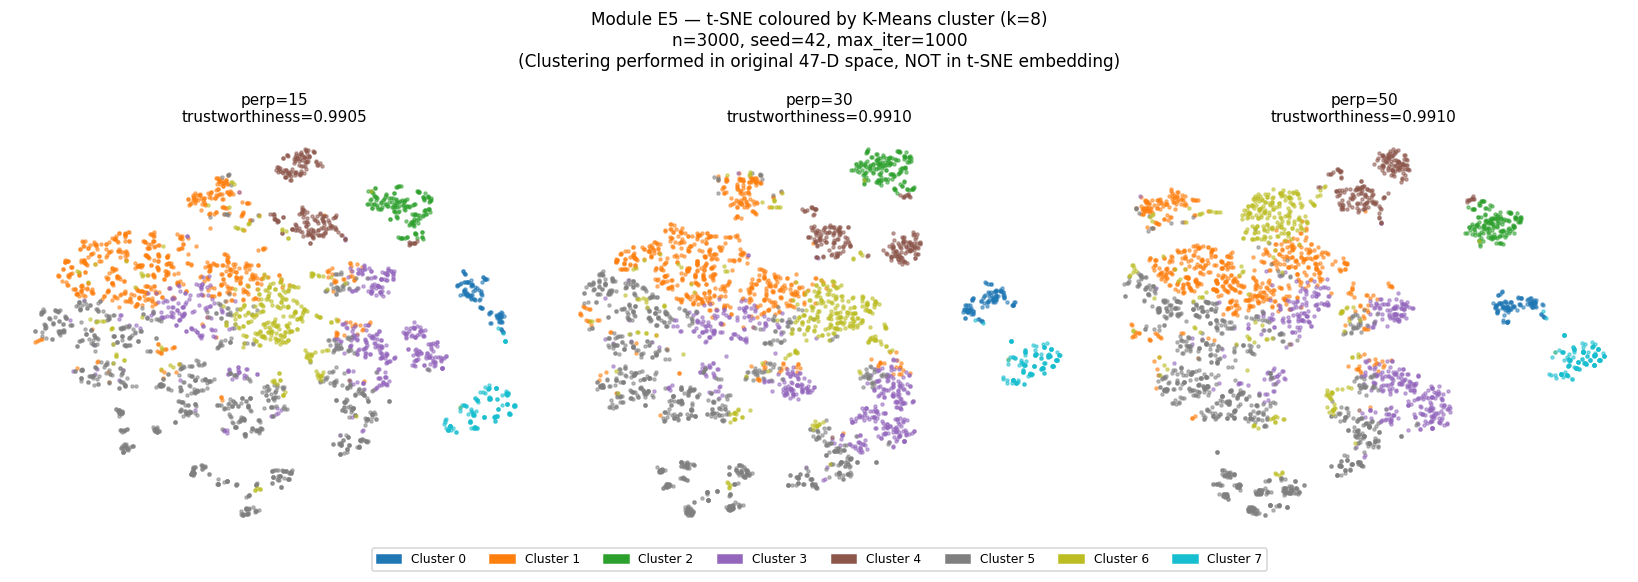

Saved: figures/tsne_kmeans_clusters.png


In [5]:
CMAP = plt.cm.get_cmap('tab10', KMEANS_K)
colours = [CMAP(i) for i in range(KMEANS_K)]

fig, axes = plt.subplots(1, len(PERPLEXITIES), figsize=(5 * len(PERPLEXITIES), 5))
for ax, perp in zip(axes, PERPLEXITIES):
    emb = tsne_embeddings[perp]
    for cl in range(KMEANS_K):
        mask = km_tsne == cl
        ax.scatter(emb[mask, 0], emb[mask, 1],
                   c=[colours[cl]], s=4, alpha=0.5, rasterized=True,
                   label=f'Cl {cl}')
    ax.set_title(f'perp={perp}\ntrustworthiness={trust_scores[perp]:.4f}', fontsize=10)
    ax.axis('off')

handles = [mpatches.Patch(color=colours[i], label=f'Cluster {i}')
           for i in range(KMEANS_K)]
fig.legend(handles=handles, loc='lower center', ncol=KMEANS_K,
           fontsize=8, bbox_to_anchor=(0.5, -0.05))
fig.suptitle(
    f'Module E5 — t-SNE coloured by K-Means cluster (k={KMEANS_K})\n'
    f'n={N_TSNE}, seed={TSNE_SEED}, max_iter={N_ITER}'
    '\n(Clustering performed in original 47-D space, NOT in t-SNE embedding)',
    fontsize=11
)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'tsne_kmeans_clusters.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: figures/tsne_kmeans_clusters.png')

## 5. Visualisation: Feature Overlays (Interpretation Support)

Using perplexity=50 (trustworthiness=0.9910)


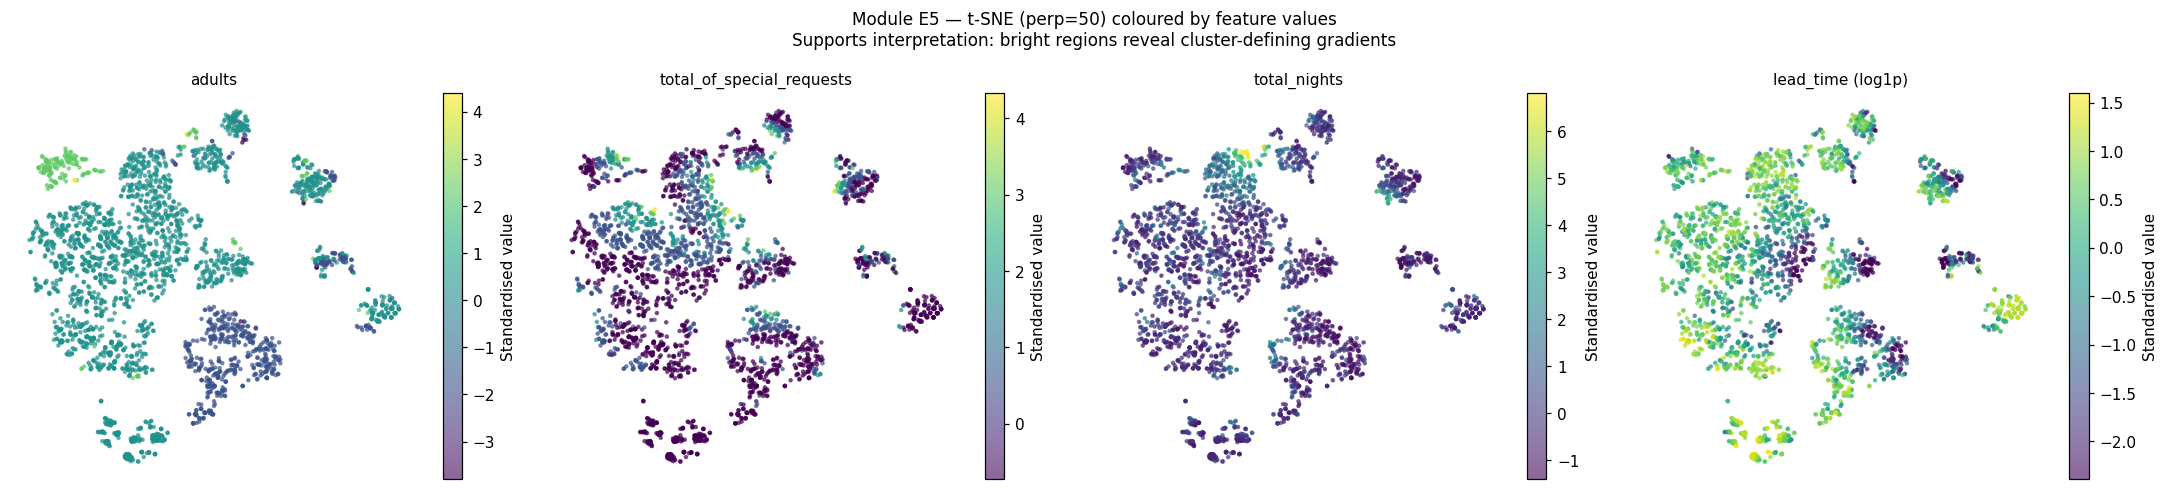

Saved: figures/tsne_feature_overlay.png


In [6]:
# Use best-trustworthiness perplexity for feature overlays
BEST_PERP = max(trust_scores, key=trust_scores.get)
emb_best  = tsne_embeddings[BEST_PERP]
print(f'Using perplexity={BEST_PERP} (trustworthiness={trust_scores[BEST_PERP]:.4f})')

# Load original (pre-preprocessing) cluster features from cluster_summary
feat_cols_num = ['lead_time', 'total_nights', 'total_of_special_requests', 'adr_mean']
feat_labels   = ['Lead time (days)', 'Total nights', 'Special requests', 'ADR (€)']

# We'll colour by cluster numeric means mapped back to the subsample
# Use the 3 most discriminative numeric columns from X_prepared
# Column indices in X_prepared: first 8 are num_regular, col 8 is num_skewed (lead_time)
# From pipeline: [adults, is_repeated_guest, prev_cancel, prev_not_cancel,
#                 req_parking, special_requests, minor_count, total_nights, lead_time]
col_map = {
    'adults'                   : 0,
    'total_of_special_requests': 5,
    'total_nights'             : 7,
    'lead_time (log1p)'        : 8,
}

fig, axes = plt.subplots(1, len(col_map), figsize=(5 * len(col_map), 4.5))
for ax, (feat_name, col_idx) in zip(axes, col_map.items()):
    vals = X_tsne[:, col_idx]
    sc = ax.scatter(emb_best[:, 0], emb_best[:, 1],
                    c=vals, cmap='viridis', s=4, alpha=0.6, rasterized=True)
    plt.colorbar(sc, ax=ax, label='Standardised value')
    ax.set_title(feat_name, fontsize=10)
    ax.axis('off')

fig.suptitle(
    f'Module E5 — t-SNE (perp={BEST_PERP}) coloured by feature values\n'
    'Supports interpretation: bright regions reveal cluster-defining gradients',
    fontsize=11
)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'tsne_feature_overlay.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: figures/tsne_feature_overlay.png')

## 6. Perplexity Sensitivity & Embedding Reliability

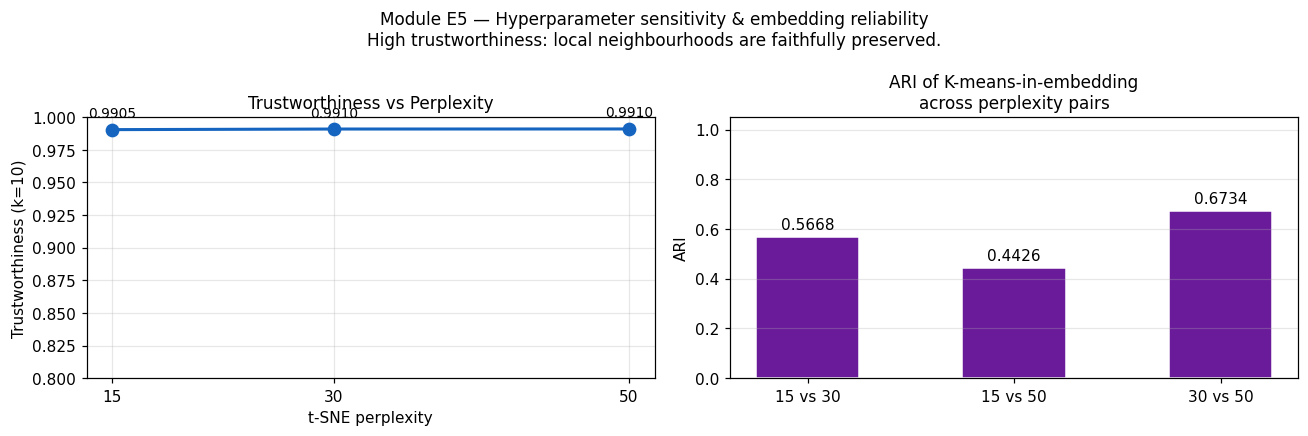

Saved: figures/tsne_sensitivity.png


In [7]:
# ── Trustworthiness vs perplexity plot ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: trustworthiness curve
ax = axes[0]
ax.plot(PERPLEXITIES, [trust_scores[p] for p in PERPLEXITIES],
        'o-', color='#1565C0', lw=2, ms=8)
ax.set_xlabel('t-SNE perplexity')
ax.set_ylabel('Trustworthiness (k=10)')
ax.set_title('Trustworthiness vs Perplexity')
ax.set_ylim(0.8, 1.0)
ax.set_xticks(PERPLEXITIES)
ax.grid(alpha=0.3)
for p, tw in trust_scores.items():
    ax.annotate(f'{tw:.4f}', (p, tw), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=9)

# Right: ARI between embeddings' cluster structures (are K-Means clusters
# consistently visible regardless of perplexity?)
# We use cluster centroids in each t-SNE embedding to assign nearest-centroid labels
# and compute ARI — a rough proxy for embedding consistency
from sklearn.cluster import KMeans as _KM
emb_labels = {}
for perp in PERPLEXITIES:
    km_emb = _KM(n_clusters=KMEANS_K, random_state=TSNE_SEED, n_init=5)
    emb_labels[perp] = km_emb.fit_predict(tsne_embeddings[perp])

ari_pairs, pair_labels = [], []
from itertools import combinations
for pa, pb in combinations(PERPLEXITIES, 2):
    ari = adjusted_rand_score(emb_labels[pa], emb_labels[pb])
    ari_pairs.append(ari)
    pair_labels.append(f'{pa} vs {pb}')

ax2 = axes[1]
bars = ax2.bar(pair_labels, ari_pairs, color='#6A1B9A', edgecolor='white', width=0.5)
ax2.bar_label(bars, fmt='%.4f', padding=3, fontsize=10)
ax2.set_ylabel('ARI')
ax2.set_title('ARI of K-means-in-embedding\nacross perplexity pairs')
ax2.set_ylim(0, 1.05)
ax2.grid(axis='y', alpha=0.3)

fig.suptitle(
    'Module E5 — Hyperparameter sensitivity & embedding reliability\n'
    'High trustworthiness: local neighbourhoods are faithfully preserved.',
    fontsize=11
)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'tsne_sensitivity.png', bbox_inches='tight')
plt.show()
print('Saved: figures/tsne_sensitivity.png')

## 7. Interpretation

The t-SNE visualisation is used **only to support interpretation** of clusters obtained in the
original 47-D space. Conclusions:
- If high-trustworthiness embeddings show well-separated coloured regions, the K-Means clusters
  are locally cohesive — consistent with the Silhouette scores in the Core evaluation.
- Feature overlays (Section 5) reveal which booking attributes (lead_time, total_nights, etc.)
  define the visual gradients, linking back to the cluster profiles in `cluster_summary.csv`.
- Overlapping regions in the embedding highlight clusters that are close in the original space,
  which informs our discussion of cluster separability limitations in the report.

**Caveat:** t-SNE faithfully preserves *local* structure but distorts *global* distances.
Two points appearing far in the t-SNE plot may be close in 47-D, and vice versa.
The trustworthiness metric quantifies this: values > 0.90 indicate reliable local preservation.

In [8]:
# ── Update experiments.csv ─────────────────────────────────────────────────
exp_path = TABLES_DIR / 'experiments.csv'
existing = pd.read_csv(exp_path) if exp_path.exists() else pd.DataFrame()
next_id  = len(existing) + 1

new_rows = []
for i, perp in enumerate(PERPLEXITIES):
    new_rows.append({
        'run_id'           : f'exp_{next_id + i:03d}',
        'representation_id': 'final_precluster_matrix',
        'method'           : 'tsne',
        'parameters'       : (
            f'n_components=2; perplexity={perp}; max_iter={N_ITER}; '
            f'init=pca; learning_rate=auto'
        ),
        'seed'             : TSNE_SEED,
        'sample_rule'      : f'stratified_subsample_n{N_TSNE}_seed{TSNE_SEED}',
        'metrics'          : (
            f'trustworthiness_k{TRUST_K}={trust_scores[perp]:.6f}; '
            f'runtime_sec={tsne_times[perp]:.2f}'
        ),
        'diagnostics'      : 'trustworthiness; perplexity_sensitivity; feature_overlay',
        'notes'            : (
            f'Module E5; visualisation only — clustering in original 47-D space; '
            f'perplexity sweep {PERPLEXITIES}'
        ),
    })

updated = pd.concat([existing, pd.DataFrame(new_rows)], ignore_index=True)
updated.to_csv(exp_path, index=False)
print(f'experiments.csv: {len(existing)} -> {len(updated)} rows')
display(pd.DataFrame(new_rows)[['run_id','method','parameters','metrics']])

experiments.csv: 17 -> 20 rows


,run_id,method,parameters,metrics
0,exp_018,tsne,n_components=2; perplexity=15; max_iter=1000; ...,trustworthiness_k10=0.990524; runtime_sec=2.52
1,exp_019,tsne,n_components=2; perplexity=30; max_iter=1000; ...,trustworthiness_k10=0.990981; runtime_sec=2.76
2,exp_020,tsne,n_components=2; perplexity=50; max_iter=1000; ...,trustworthiness_k10=0.991032; runtime_sec=3.10


## 8. Module E5 Checklist

- [x] t-SNE used **for visualisation only** — no clustering in the embedding
- [x] Perplexity sweep {15, 30, 50} — trustworthiness for each → `tables/tsne_trustworthiness.csv`
- [x] Trustworthiness-style diagnostic explicitly reported and discussed
- [x] Visualisation coloured by K-Means cluster → `figures/tsne_kmeans_clusters.png`
- [x] Feature overlay to link visual gradients to cluster profiles → `figures/tsne_feature_overlay.png`
- [x] Sensitivity figure (trustworthiness vs perplexity) → `figures/tsne_sensitivity.png`
- [x] Hyperparameter dependence discussed (Section 7 caveat)
- [x] `experiments.csv` updated